# Notebook 03: Model 1 — Soft Sensor for Final Moisture

**Project:** MAP Dryer AI  
**Purpose:** compare regression models that estimate `final_moisture_h₂o` from MAP dryer process measurements.

A soft sensor is a model-based estimate of a measurement from related process variables. In this prototype, moisture values are **percentage points**: `0.075` means `0.075% H2O`, not `7.5%`.

## Inputs and evaluation approach

- **Input:** `data/processed/dryerMAP_prototype_processed_2.csv` (created in Notebook 02)
- **Target:** `final_moisture_h₂o` in `% H2O`
- **Models compared:** Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting
- **Evaluation:** chronological 80/20 holdout split plus time-series cross-validation inside training
- **Figure outputs:** `figures/03_Model1_SoftSensor/`
- **Prototype feature dictionary:** `config/data_dictionary.yaml`

Time-series cross-validation is used during model selection; the final chronological holdout remains separate until the selected model is evaluated.


## 1. Import libraries and locate the project root

Load the modelling, evaluation, visualisation, and interpretation libraries. The project root is found dynamically so the notebook can run from the repository root or the `notebooks/` directory.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import max_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SRC_DIR = next(
    candidate / "src" for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "src" / "canonical_pipeline.py").exists()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from canonical_pipeline import (
    ALIGNED_PATH, train_final_model, validate_moisture_runtime_contract
)
from multirate import MOISTURE_FEATURE_NAMES
from data.feature_catalog import feature_axis_label, load_feature_catalog, select_feature_catalog
from data.project_paths import find_project_root
from stats.descriptive_statistics import descriptive_summary
from models.regression import calculate_regression_metrics

PROJECT_ROOT = find_project_root()
FIGURE_OUTPUT_DIR = PROJECT_ROOT / "figures" / "03_Model1_SoftSensor"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DICTIONARY_PATH = PROJECT_ROOT / "config" / "data_dictionary.yaml"
feature_catalog = load_feature_catalog(DATA_DICTIONARY_PATH)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Prototype feature dictionary


In [2]:
SOFT_SENSOR_FIELDS = [
    "timestamp", "dryer_air_temperature", "cooler_air_temperature",
    "air_flow_rate", "wet_product_feed_rate", "product_inlet_temperature",
    "residence_time", "vacuum", "steam_pressure", "fan_speed",
    "product_density", "final_product_temp", "temperature_drop",
    "air_product_delta", "air_per_feed", "steam_temp_interaction",
    "heating_index", "final_moisture_h₂o",
]
display(select_feature_catalog(feature_catalog, SOFT_SENSOR_FIELDS))
print("Data dictionary version:", feature_catalog.attrs["version"])


,display_name,unit,unit_status,role,interpretation
feature,,,,,
timestamp,Timestamp,datetime,defined,identifier,Date and time combined for chronological order...
dryer_air_temperature,Dryer air temperature,°C,prototype_unit,process_input,Dryer inlet-air temperature.
cooler_air_temperature,Cooler air temperature,°C,prototype_unit,process_input,Cooling-air temperature.
air_flow_rate,Air flow rate,m³/h,defined,process_input,Volumetric airflow rate in cubic metres per hour.
wet_product_feed_rate,Wet product feed rate,m³/h,defined,process_input,Volumetric wet-product feed rate in cubic metr...
product_inlet_temperature,Product inlet temperature,°C,prototype_unit,process_input,Product temperature at dryer entry.
residence_time,Residence time,min,prototype_unit,process_input,Time spent in the drying process.
vacuum,Vacuum,mmH2O,defined,process_input,Vacuum in millimetres of water column; more-ne...
steam_pressure,Steam pressure,bar,defined,process_input,Steam pressure in bar.


Data dictionary version: map_dryer_data_dictionary_v1.2


### Interpretation guardrails

- MAE, RMSE, and maximum error are measured in moisture percentage points (`% H2O`); R² is unitless.
- Time-series cross-validation guides model selection; the final chronological holdout is evaluated separately.
- Feature importance and SHAP explain model behaviour, not physical causation.


## 2. Load the governed Notebook 02 feature table

Read the 1,103-row table produced from the canonical 92-day source. It retains
the original 16 Notebook 02 features without mean/std/last suffixes.


In [3]:
DATA_PATH = ALIGNED_PATH
dryerMAP_model = pd.read_csv(DATA_PATH, parse_dates=["Sample Timestamp"])
dryerMAP_model = dryerMAP_model.rename(columns={
    "Sample Timestamp": "timestamp",
    "Final Moisture (%H2O)": "final_moisture_hâ‚‚o",
})
dryerMAP_model.insert(0, "time", dryerMAP_model["timestamp"].dt.time.astype(str))
dryerMAP_model.insert(0, "date", dryerMAP_model["timestamp"].dt.normalize())
display(dryerMAP_model.head())
dryerMAP_model.info()


,date,time,timestamp,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index,final_moisture_hâ‚‚o
0,2026-04-16,02:00:00,2026-04-16 02:00:00,176.386871,28.788322,24080.34375,26.614941,62.906261,24.438337,48.143120,8.348623,1333.375977,0.957827,48.819279,127.567592,113.480610,904.767880,1472.587488,4310.601796,0.078586
1,2026-04-16,04:00:00,2026-04-16 04:00:00,176.325211,29.371353,24131.47461,26.710299,63.091366,24.397861,48.377773,8.376637,1339.708374,0.957757,49.183418,127.141793,113.233845,903.452058,1477.012286,4301.957989,0.077713
2,2026-04-16,06:00:00,2026-04-16 06:00:00,176.298935,30.183477,24223.72266,26.746771,63.173382,24.372213,48.470203,8.392202,1340.537598,0.957155,49.281967,127.016968,113.125553,905.669049,1479.536275,4296.795195,0.077810
3,2026-04-16,08:00:00,2026-04-16 08:00:00,176.333313,30.894432,24237.87891,26.783215,63.224796,24.393484,48.433044,8.335905,1342.057739,0.957491,48.769199,127.564114,113.108517,904.965252,1469.897746,4301.383849,0.075195
4,2026-04-16,10:00:00,2026-04-16 10:00:00,176.263535,31.169731,24271.02930,26.897886,63.118942,24.396927,48.482235,8.400537,1346.523071,0.958166,48.747028,127.516507,113.144593,902.339660,1480.708348,4300.288596,0.079999


<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1103 non-null   datetime64[us]
 1   time                       1103 non-null   str           
 2   timestamp                  1103 non-null   datetime64[us]
 3   dryer_air_temperature      1103 non-null   float64       
 4   cooler_air_temperature     1103 non-null   float64       
 5   air_flow_rate              1103 non-null   float64       
 6   wet_product_feed_rate      1103 non-null   float64       
 7   product_inlet_temperature  1103 non-null   float64       
 8   residence_time             1103 non-null   float64       
 9   vacuum                     1103 non-null   float64       
 10  steam_pressure             1103 non-null   float64       
 11  fan_speed                  1103 non-null   float64       
 12  product_density  

## 3. Review the modelling dataset

Confirm the number of observations and columns, then inspect descriptive statistics before defining the prediction task.


In [4]:
print(f"Rows: {dryerMAP_model.shape[0]}")
print(f"Columns: {dryerMAP_model.shape[1]}")


descriptive_summary(dryerMAP_model)


Rows: 1103
Columns: 20


,count,mean,std,variance,min,25%,50%,75%,max,skewness,excess_kurtosis
dryer_air_temperature,1103.0,176.184848,0.327078,1.069800e-01,175.362030,175.955010,176.193619,176.417633,177.086151,-0.044581,-0.401137
cooler_air_temperature,1103.0,29.524461,1.073701,1.152833e+00,27.656775,28.524258,29.523249,30.500409,32.992344,0.067082,-1.143793
air_flow_rate,1103.0,23918.192699,252.084888,6.354679e+04,23274.761720,23736.052735,23924.484380,24110.865230,24561.880860,-0.028871,-0.584535
wet_product_feed_rate,1103.0,26.065711,0.730766,5.340185e-01,24.535093,25.496433,26.275084,26.625887,27.594671,-0.036062,-1.009779
product_inlet_temperature,1103.0,62.906174,0.183932,3.383092e-02,62.426342,62.776415,62.907501,63.045740,63.379189,-0.056045,-0.548661
residence_time,1103.0,24.537119,0.131159,1.720281e-02,24.243851,24.436083,24.527617,24.643286,24.844101,0.047921,-0.932065
vacuum,1103.0,48.118793,0.265637,7.056307e-02,47.402889,47.933283,48.118370,48.313734,48.860847,-0.041041,-0.408879
steam_pressure,1103.0,8.250629,0.124204,1.542654e-02,7.875011,8.151324,8.257105,8.346998,8.560302,-0.040258,-0.806308
fan_speed,1103.0,1326.276904,14.298728,2.044536e+02,1288.390381,1314.338318,1326.589355,1337.998230,1361.949951,-0.033935,-0.841550
product_density,1103.0,0.957074,0.000961,9.237940e-07,0.954389,0.956327,0.957068,0.957838,0.959317,-0.059246,-0.778305


## 4. Define the prediction target and governed features

The target is final moisture. The explicit list below is your original feature
set from Notebook 02 and is also the ordered runtime contract.


In [5]:
TARGET = "final_moisture_hâ‚‚o"
FEATURES = [
    "dryer_air_temperature",
    "cooler_air_temperature",
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed",
    "product_density",
    "final_product_temp",
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "steam_temp_interaction",
    "heating_index",
]
assert FEATURES == list(MOISTURE_FEATURE_NAMES)
MOISTURE_UNIT = "percentage points (% H2O)"
print(f"Target: {TARGET}; features: {len(FEATURES)}")


Target: final_moisture_hâ‚‚o; features: 16


## 5. Build the feature matrix and target vector

Separate the selected predictors (`X`) from the final-moisture target (`y`) and confirm their dimensions.


In [6]:
X = dryerMAP_model[FEATURES]

y = dryerMAP_model[TARGET]

print(X.shape)
print(y.shape)


(1103, 16)
(1103,)


## 6. Create chronological TRAIN, VALIDATION, and TEST splits

Use the first 70% for training, the next 15% for model-family validation, and
the final 15% once for testing. No observations are shuffled.


In [7]:
n_train = int(round(len(dryerMAP_model) * 0.70))
validation_stop = int(round(len(dryerMAP_model) * 0.85))
n_validation = validation_stop - n_train

X_train, y_train = X.iloc[:n_train], y.iloc[:n_train]
X_validation, y_validation = X.iloc[n_train:validation_stop], y.iloc[n_train:validation_stop]
X_test, y_test = X.iloc[validation_stop:], y.iloc[validation_stop:]

print("Training samples   :", len(X_train))
print("Validation samples :", len(X_validation))
print("Testing samples    :", len(X_test))


Training samples   : 772
Validation samples : 166
Testing samples    : 165


## 7. Scale inputs for linear models

Standardisation is fitted only on the training data and then applied to the test data. Tree-based models below use the original, unscaled features because they do not require scaling.


In [8]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_validation_scaled = pd.DataFrame(
    scaler.transform(X_validation), columns=X_validation.columns, index=X_validation.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)
print("Training features standardized:", X_train_scaled.shape)
print("Validation features standardized:", X_validation_scaled.shape)
print("Testing features standardized:", X_test_scaled.shape)


Training features standardized: (772, 16)
Validation features standardized: (166, 16)
Testing features standardized: (165, 16)


## 8. Baseline model 1: Linear Regression

Train a simple linear baseline, calculate holdout metrics, and inspect residual errors over time. This establishes a transparent reference point for the more flexible models.


In [9]:
baseline_linear_model = LinearRegression()
baseline_linear_model.fit(X_train_scaled, y_train)

y_pred_linear = baseline_linear_model.predict(X_test_scaled)

print("Linear Regression baseline trained.")


Linear Regression baseline trained.


In [10]:
baseline_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_linear)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_linear))],
        "R²": [r2_score(y_test, y_pred_linear)],
        "Maximum absolute error": [max_error(y_test, y_pred_linear)],
    },
    index=["Linear Regression"],
)

display(baseline_metrics.round(4))


,MAE,RMSE,R²,Maximum absolute error
Linear Regression,0.0011,0.0014,0.824,0.0057


C:\Users\pc\AppData\Local\Temp\ipykernel_11528\3657850750.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(error_analysis_linear.round(4))


,timestamp,Actual moisture,Predicted moisture,Residual (actual - predicted),Absolute error
938,2026-07-03 06:00:00,0.0749,0.0758,-0.0009,0.0009
939,2026-07-03 08:00:00,0.0739,0.0771,-0.0031,0.0031
940,2026-07-03 10:00:00,0.0755,0.0773,-0.0018,0.0018
941,2026-07-03 12:00:00,0.0800,0.0777,0.0023,0.0023
942,2026-07-03 14:00:00,0.0774,0.0763,0.0011,0.0011
...,...,...,...,...,...
1098,2026-07-16 14:00:00,0.0752,0.0767,-0.0015,0.0015
1099,2026-07-16 16:00:00,0.0736,0.0771,-0.0035,0.0035
1100,2026-07-16 18:00:00,0.0744,0.0762,-0.0017,0.0017
1101,2026-07-16 20:00:00,0.0739,0.0755,-0.0017,0.0017


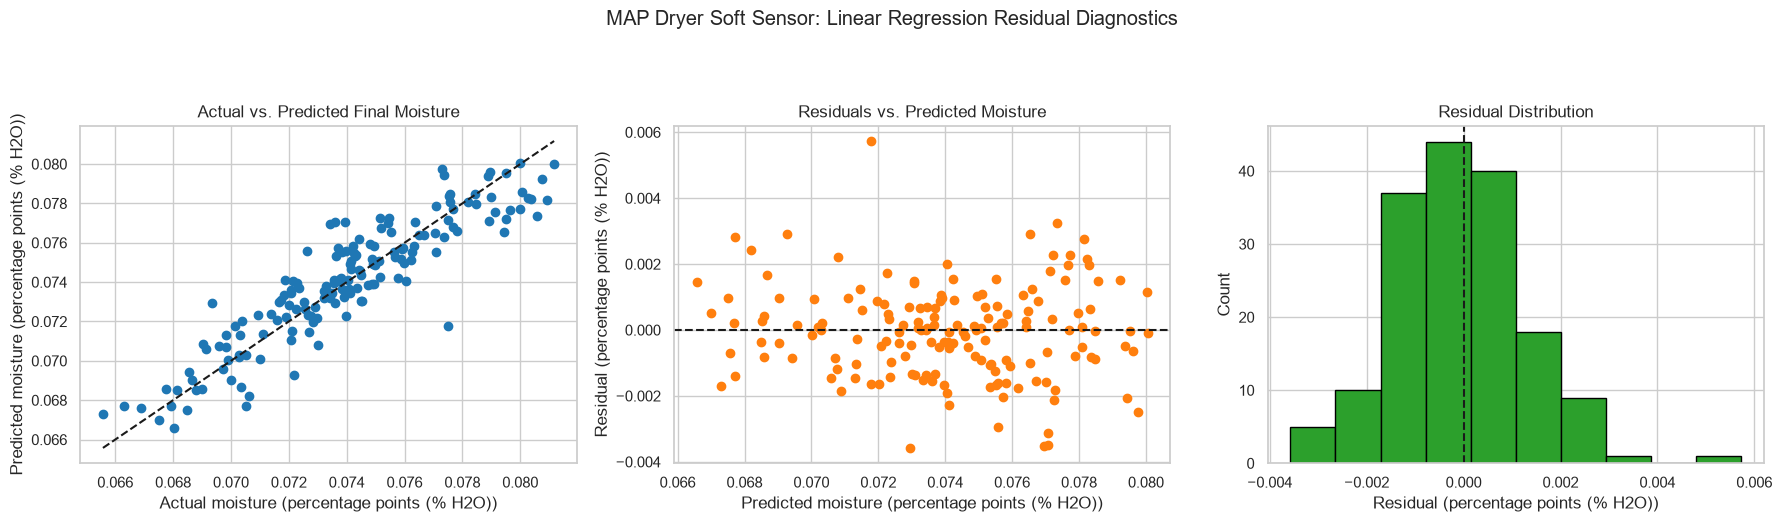

In [11]:
residuals_linear = y_test - y_pred_linear
error_analysis_linear = pd.DataFrame(
    {
        "timestamp": dryerMAP_model.loc[y_test.index, "timestamp"],
        "Actual moisture": y_test,
        "Predicted moisture": y_pred_linear,
        "Residual (actual - predicted)": residuals_linear,
        "Absolute error": residuals_linear.abs(),
    }
)
display(error_analysis_linear.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MAP Dryer Soft Sensor: Linear Regression Residual Diagnostics", y=1.04)

axis_min = min(y_test.min(), y_pred_linear.min())
axis_max = max(y_test.max(), y_pred_linear.max())
axes[0].scatter(y_test, y_pred_linear, color="tab:blue")
axes[0].plot([axis_min, axis_max], [axis_min, axis_max], "k--")
axes[0].set(xlabel=f"Actual moisture ({MOISTURE_UNIT})", ylabel=f"Predicted moisture ({MOISTURE_UNIT})", title="Actual vs. Predicted Final Moisture")

axes[1].scatter(y_pred_linear, residuals_linear, color="tab:orange")
axes[1].axhline(0, color="k", linestyle="--")
axes[1].set(xlabel=f"Predicted moisture ({MOISTURE_UNIT})", ylabel=f"Residual ({MOISTURE_UNIT})", title="Residuals vs. Predicted Moisture")

axes[2].hist(residuals_linear, bins=min(10, len(residuals_linear)), color="tab:green", edgecolor="black")
axes[2].axvline(0, color="k", linestyle="--")
axes[2].set(xlabel=f"Residual ({MOISTURE_UNIT})", ylabel="Count", title="Residual Distribution")

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_linear_regression_residual_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 9. Baseline model 2: Ridge Regression

Fit a regularised linear model and evaluate it on the same untouched holdout period. Ridge regression can reduce instability when predictor variables are correlated.


In [12]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge baseline trained.")


Ridge baseline trained.


In [13]:
ridge_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_ridge)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_ridge))],
        "R²": [r2_score(y_test, y_pred_ridge)],
        "Maximum absolute error": [max_error(y_test, y_pred_ridge)],
    },
    index=["Ridge Regression"],
)

display(ridge_metrics.round(4))


,MAE,RMSE,R²,Maximum absolute error
Ridge Regression,0.0011,0.0014,0.82,0.0057


## 10. Baseline model 3: Random Forest

Train an ensemble of decision trees to capture nonlinear relationships and interactions among the dryer variables, then calculate the same holdout metrics for a fair comparison.


In [14]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

random_forest_model.fit(X_train, y_train)
y_pred_random_forest = random_forest_model.predict(X_test)

print("Random Forest baseline trained.")


Random Forest baseline trained.


In [15]:
random_forest_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_random_forest)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_random_forest))],
        "R²": [r2_score(y_test, y_pred_random_forest)],
        "Maximum absolute error": [max_error(y_test, y_pred_random_forest)],
    },
    index=["Random Forest"],
)

display(random_forest_metrics.round(4))


,MAE,RMSE,R²,Maximum absolute error
Random Forest,0.0011,0.0014,0.816,0.0054


## 11. Baseline model 4: Gradient Boosting

Train a boosting model that builds small decision trees sequentially. Its performance is evaluated with the same holdout set and error measures as the other candidates.


In [16]:
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)

gradient_boosting_model.fit(X_train, y_train)
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

print("Gradient Boosting baseline trained.")


Gradient Boosting baseline trained.


In [17]:
gradient_boosting_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_gradient_boosting)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_gradient_boosting))],
        "R²": [r2_score(y_test, y_pred_gradient_boosting)],
        "Maximum absolute error": [max_error(y_test, y_pred_gradient_boosting)],
    },
    index=["Gradient Boosting"],
)

display(gradient_boosting_metrics.round(4))


,MAE,RMSE,R²,Maximum absolute error
Gradient Boosting,0.0012,0.0015,0.8051,0.0051


## 12. Baseline model 5: Elastic Net

Train Elastic Net in its own cell and display its holdout metrics in the next
cell, following the same structure as the other four baseline models.


In [18]:
elastic_net_model = ElasticNet(
    alpha=0.0001,
    l1_ratio=0.8,
    max_iter=100000,
    tol=1e-7,
    random_state=42,
)
elastic_net_model.fit(X_train_scaled, y_train)
y_pred_elastic_net = elastic_net_model.predict(X_test_scaled)

print("Elastic Net baseline trained.")

Elastic Net baseline trained.


In [19]:
elastic_net_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_elastic_net)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_elastic_net))],
        "R²": [r2_score(y_test, y_pred_elastic_net)],
        "Maximum absolute error": [max_error(y_test, y_pred_elastic_net)],
    },
    index=["Elastic Net"],
)

display(elastic_net_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Elastic Net,0.0011,0.0014,0.8191,0.0055


In [20]:
model_comparison = pd.concat(
    [
        baseline_metrics,
        ridge_metrics,
        random_forest_metrics,
        gradient_boosting_metrics,
        elastic_net_metrics,
    ]
).sort_values("RMSE")

display(model_comparison.round(4))
print(f"Best current model by RMSE: {model_comparison.index[0]}")


,MAE,RMSE,R²,Maximum absolute error
Linear Regression,0.0011,0.0014,0.8240,0.0057
Ridge Regression,0.0011,0.0014,0.8200,0.0057
Elastic Net,0.0011,0.0014,0.8191,0.0055
Random Forest,0.0011,0.0014,0.8160,0.0054
Gradient Boosting,0.0012,0.0015,0.8051,0.0051


Best current model by RMSE: Linear Regression


## 13. Validate with time-series cross-validation

Use expanding time-series splits within the training data to estimate how each model performs across multiple forward-looking validation periods. MAE, RMSE, and R² are reported for each candidate.


In [21]:
tscv = TimeSeriesSplit(n_splits=5)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R²": "r2"}
cv_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Elastic Net": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.0001, l1_ratio=0.8, max_iter=100000, tol=1e-7)),
    ]),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42
    ),
}
cv_rows = []
for model_name, model in cv_models.items():
    scores = cross_validate(model, X_train, y_train, cv=tscv, scoring=scoring)
    cv_rows.append({
        "Model": model_name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R²"].mean(),
    })
cross_validation_results = pd.DataFrame(cv_rows).set_index("Model").sort_values("CV RMSE")
display(cross_validation_results.round(4))


,CV MAE,CV RMSE,CV R²
Model,,,
Elastic Net,0.0011,0.0014,0.8496
Ridge Regression,0.0011,0.0014,0.8473
Linear Regression,0.0011,0.0015,0.8389
Gradient Boosting,0.0012,0.0016,0.8179
Random Forest,0.0012,0.0016,0.8013


## 14. Tune the nonlinear and regularised candidates

Use the same five-fold time-series validation to tune Ridge, Elastic Net,
Random Forest, and Gradient Boosting inside the TRAIN period.


In [22]:
tuning_searches = {
    "Ridge Regression": GridSearchCV(
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
        scoring="neg_root_mean_squared_error",
        cv=tscv,
    ),
    "Elastic Net": GridSearchCV(
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=100000, tol=1e-7, random_state=42)),
        ]),
        param_grid={
            "model__alpha": [0.0001, 0.0003, 0.001, 0.003, 0.01],
            "model__l1_ratio": [0.2, 0.5, 0.8],
        },
        scoring="neg_root_mean_squared_error",
        cv=tscv,
    ),
    "Random Forest": GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid={
            "n_estimators": [100, 200],
            "max_depth": [None, 3],
            "min_samples_leaf": [1, 2],
        },
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
    ),
    "Gradient Boosting": GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        param_grid={
            "n_estimators": [50, 100],
            "learning_rate": [0.03, 0.05],
            "max_depth": [1, 2],
        },
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
    ),
}

tuning_rows = []
for model_name, search in tuning_searches.items():
    search.fit(X_train, y_train)
    tuning_rows.append({
        "Model": model_name,
        "Best CV RMSE": -search.best_score_,
        "Best parameters": search.best_params_,
    })

tuning_results = pd.DataFrame(tuning_rows).set_index("Model").sort_values("Best CV RMSE")
display(tuning_results)


,Best CV RMSE,Best parameters
Model,,
Elastic Net,0.001397,"{'model__alpha': 0.0001, 'model__l1_ratio': 0.5}"
Ridge Regression,0.001405,{'model__alpha': 10.0}
Gradient Boosting,0.001552,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
Random Forest,0.001610,"{'max_depth': None, 'min_samples_leaf': 2, 'n_..."


## 15. Select and refit the final candidate

The canonical selection routine tunes every candidate with five training-only
time-series folds, selects the family by the later VALIDATION RMSE, refits on
TRAIN plus VALIDATION, evaluates TEST once, and exports that exact artifact.


In [23]:
final_model, evaluation = train_final_model()
final_model_name = evaluation["selected_model"]
selection_results = pd.DataFrame({
    name: {
        "Training-fold CV RMSE": result["time_series_cv_rmse"],
        "VALIDATION RMSE": result["validation"]["rmse"],
    }
    for name, result in evaluation["candidate_results"].items()
}).T.sort_values("VALIDATION RMSE")
display(selection_results)
print(f"Selected final candidate: {final_model_name}")


,Training-fold CV RMSE,VALIDATION RMSE
Ridge,0.001405,0.001357
Elastic Net,0.001397,0.001362
Linear Regression,0.001457,0.001367
Gradient Boosting,0.001537,0.001430
Random Forest,0.001583,0.001467


Selected final candidate: Ridge


## 16. Inspect global feature importance

Rank the influence of input features in the selected model. For tree models this is impurity-based importance; for linear models it is the absolute standardised coefficient. These scores describe model behaviour, not causal effects.


,Feature,Importance
0,air_per_feed,0.001247
1,wet_product_feed_rate,0.001045
2,cooler_air_temperature,0.000539
3,dryer_air_temperature,0.000443
4,air_product_delta,0.000321
5,temperature_drop,0.000274
6,heating_index,0.000234
7,air_flow_rate,0.000223
8,product_inlet_temperature,0.000217
9,steam_pressure,0.000206


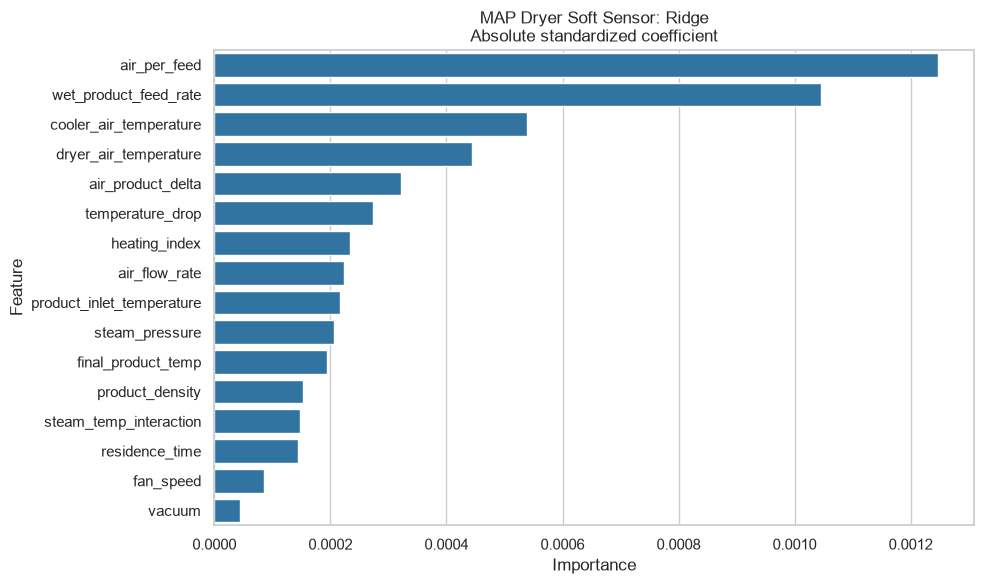

In [24]:
final_estimator = (
    final_model.named_steps["model"]
    if isinstance(final_model, Pipeline)
    else final_model
)

if hasattr(final_estimator, "feature_importances_"):
    importance_values = final_estimator.feature_importances_
    importance_method = "Impurity-based feature importance"
elif hasattr(final_estimator, "coef_"):
    importance_values = np.abs(np.ravel(final_estimator.coef_))
    importance_method = "Absolute standardized coefficient"
else:
    raise TypeError(f"Feature importance is not available for {final_model_name}.")

feature_importance = (
    pd.DataFrame({"Feature": X_train.columns, "Importance": importance_values})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature", color="tab:blue")
plt.title(f"MAP Dryer Soft Sensor: {final_model_name}\n{importance_method}")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "02_selected_model_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 17. Explain predictions with SHAP

SHAP summaries show how strongly each feature contributes to the selected model's predictions across the training data. Use them to understand model patterns, while keeping normal process-engineering validation in the loop.


Background dataset has 772 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=772 when initializing the masker.


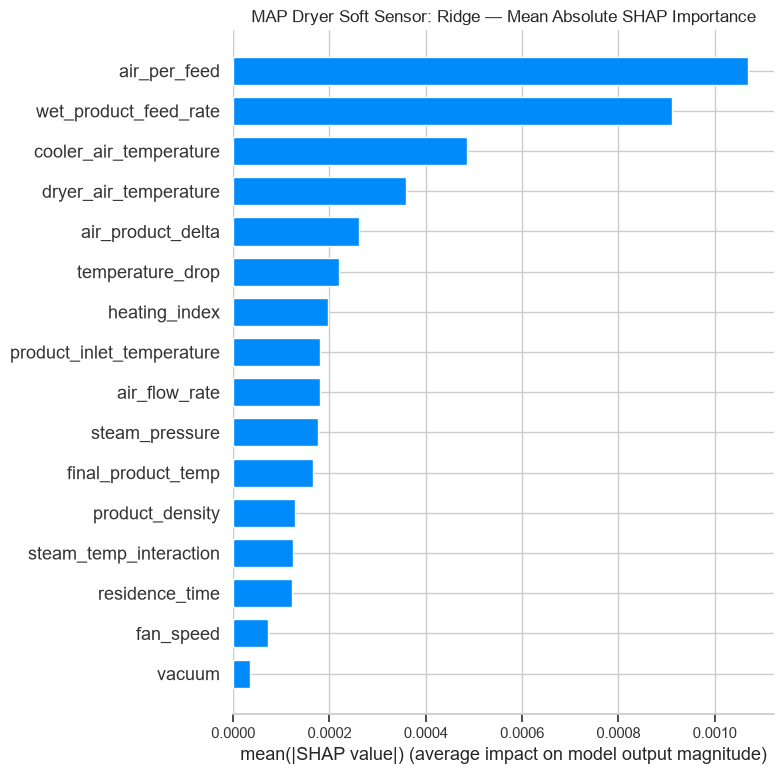

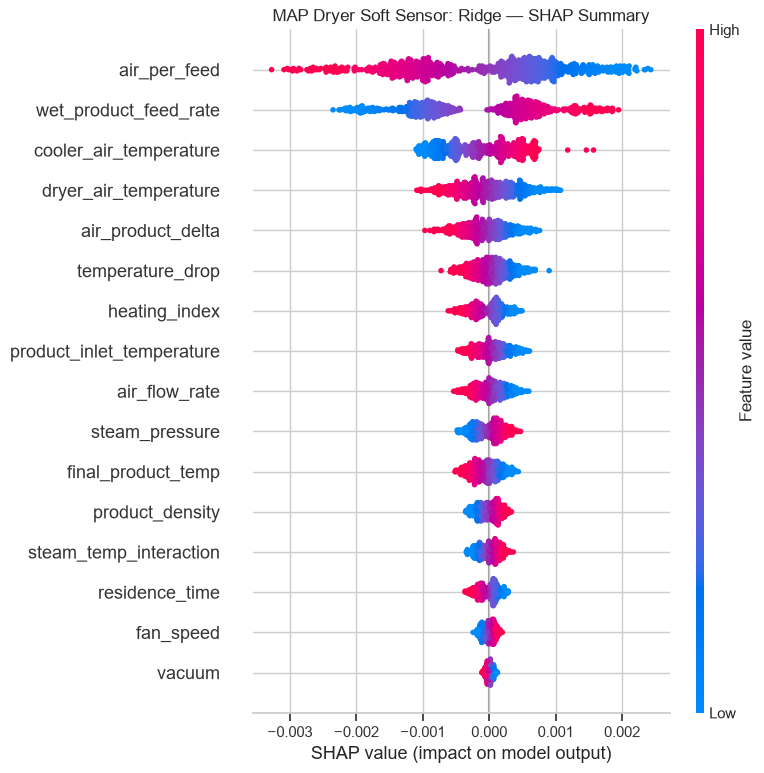

In [25]:
if hasattr(final_estimator, "feature_importances_"):
    X_explain = X_train
    shap_explainer = shap.TreeExplainer(final_estimator)
    shap_values = shap_explainer.shap_values(X_explain)
elif isinstance(final_model, Pipeline) and "scaler" in final_model.named_steps:
    X_explain = pd.DataFrame(
        final_model.named_steps["scaler"].transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    shap_explainer = shap.LinearExplainer(final_estimator, X_explain)
    shap_values = shap_explainer.shap_values(X_explain)
else:
    X_explain = X_train
    shap_explainer = shap.LinearExplainer(final_estimator, X_explain)
    shap_values = shap_explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.title(f"MAP Dryer Soft Sensor: {final_model_name} — Mean Absolute SHAP Importance")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "03_selected_model_shap_global_importance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

shap.summary_plot(shap_values, X_explain, show=False)
plt.title(f"MAP Dryer Soft Sensor: {final_model_name} — SHAP Summary")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "04_selected_model_shap_summary.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 18. Final evaluation on the untouched test period

Evaluate the selected model once on the held-out chronological test set using MAE, RMSE, R², and maximum absolute error. The time-series plot compares predicted and actual final moisture over that period.


,MAE,RMSE,R²,Maximum absolute error
Ridge,0.001069,0.001403,0.82453,0.005621


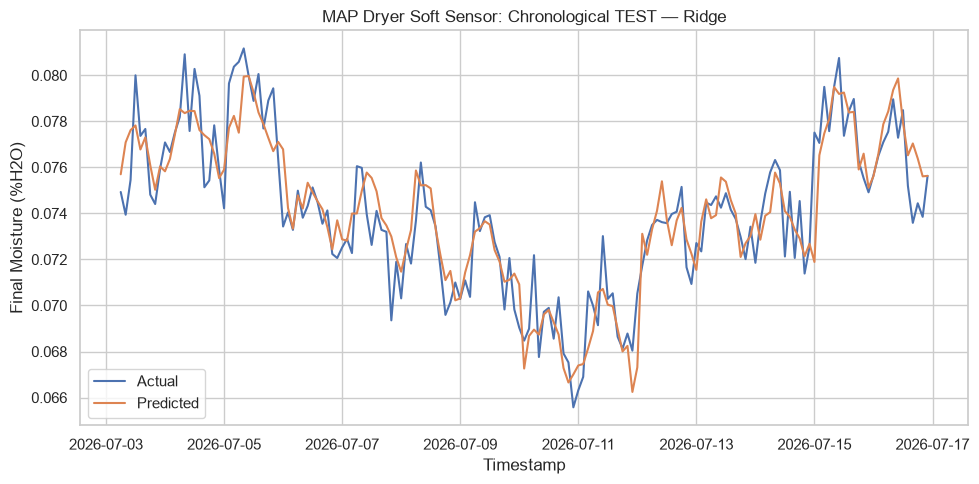

In [26]:
y_pred_final = final_model.predict(X_test)
final_test_metrics = pd.DataFrame({
    "MAE": [mean_absolute_error(y_test, y_pred_final)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_final))],
    "R²": [r2_score(y_test, y_pred_final)],
    "Maximum absolute error": [max_error(y_test, y_pred_final)],
}, index=[final_model_name])
final_test_predictions = pd.DataFrame({
    "timestamp": dryerMAP_model.loc[y_test.index, "timestamp"],
    "Actual moisture": y_test,
    "Predicted moisture": y_pred_final,
    "Residual (actual - predicted)": y_test - y_pred_final,
})
display(final_test_metrics.round(6))
plt.figure(figsize=(10, 5))
plt.plot(final_test_predictions["timestamp"], final_test_predictions["Actual moisture"], label="Actual")
plt.plot(final_test_predictions["timestamp"], final_test_predictions["Predicted moisture"], label="Predicted")
plt.title(f"MAP Dryer Soft Sensor: Chronological TEST — {final_model_name}")
plt.xlabel("Timestamp")
plt.ylabel("Final Moisture (%H2O)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_OUTPUT_DIR / "05_final_holdout_predictions.png", dpi=300, bbox_inches="tight")
plt.show()


## 19. Check for overfitting across training, validation, and testing

Compare the selected model on the data used to fit it, out-of-fold predictions from the chronological validation splits, and the untouched test period. Large increases in RMSE together with decreases in R2 from training to validation or testing are evidence that the model may be overfitting. The warning below uses a transparent heuristic: an RMSE increase greater than 20% and an R2 decrease greater than 0.10.


,Samples,mae,rmse,r2,bias,max_abs_error,n
train,772,0.001087,0.001414,0.878173,0.000000,0.006093,772.0
validation,166,0.001031,0.001357,0.895937,-0.000042,0.005533,166.0
test,165,0.001069,0.001403,0.824530,0.000066,0.005621,165.0


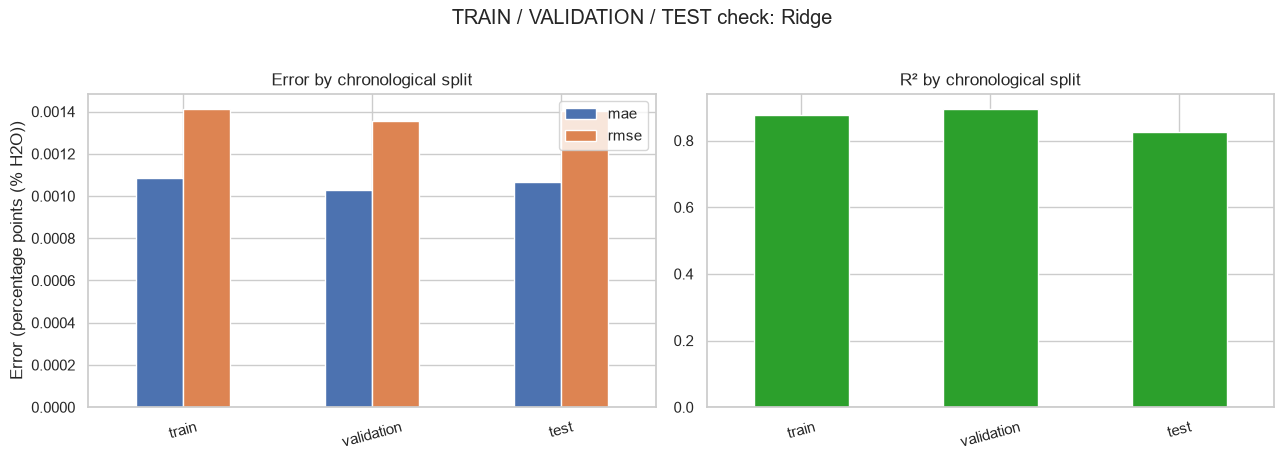

In [27]:
train_validation_test_metrics = pd.DataFrame(evaluation["metrics"]).T
train_validation_test_metrics.insert(
    0, "Samples", [evaluation["metrics"][name]["n"] for name in ["train", "validation", "test"]]
)
display(train_validation_test_metrics.round(6))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
train_validation_test_metrics[["mae", "rmse"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Error by chronological split")
axes[0].set_ylabel(f"Error ({MOISTURE_UNIT})")
train_validation_test_metrics["r2"].plot(kind="bar", ax=axes[1], rot=15, color="tab:green")
axes[1].set_title("R² by chronological split")
axes[1].axhline(0, color="black", linewidth=0.8)
fig.suptitle(f"TRAIN / VALIDATION / TEST check: {final_model_name}", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_OUTPUT_DIR / "06_train_validation_test_overfitting_check.png", dpi=300, bbox_inches="tight")
plt.show()


## Next step

Notebook 04 consumes the Notebook 03 evaluation record, trains the authoritative
process-only anomaly/diagnosis artifacts, and validates the complete runtime
bundle on the held-out chronological TEST replay.


In [28]:
contract_checks = validate_moisture_runtime_contract()
display(pd.Series({
    **contract_checks,
    "selected_model": evaluation["selected_model"],
    "model_artifact": evaluation["model_artifact"],
    "feature_count": evaluation["feature_count"],
    "test_replay": evaluation["test_replay"]["path"],
}, name="Notebook 03 export"))


feature_count_16                                                                True
schema_order_matches                                                            True
model_input_order_matches                                                       True
artifact_hash_matches                                                           True
runtime_same_notebook03_artifact                                                True
test_replay_exists                                                              True
test_replay_is_derived_from_canonical                                           True
selected_model                                                                 Ridge
model_artifact                            models\5s\quality_moisture_pipeline.joblib
feature_count                                                                     16
test_replay                              data\processed\MAP_Dryer_TEST_Replay_5s.csv
Name: Notebook 03 export, dtype: object